In [1]:
import pandas as pd       
import matplotlib.pyplot as plt  
import numpy as np           
from scipy import stats
import seaborn as sns
sns.set_theme(context='talk',style='whitegrid') #,font_scale=1.2)

In [2]:
# Define function to load and preprocess data
def load_and_preprocess_data(center,basepath='results',mode='flagged_vs_unflagged'):
    
    """Load 'complaint_with_mask_and_vitals_CENTER.csv' data and preprocess"""
    
    # Load data
    filename = f"{basepath}/{center}/{mode}/complaint_with_mask_and_vitals_{center}.csv" 
    # filename = f"{basepath}/complaint_with_mask_and_vitals_{center}.csv" 
    data = pd.read_csv(filename)
    
    # Add severity flag
    data['final_mask_corrected'] = data['final_mask_corrected'].fillna(False).astype(bool)
    data['danger_zone_vitals'] = data['danger_zone_vitals'].fillna(False).astype(bool)
    data['any_flagged'] = (data['final_mask_corrected'] | data['danger_zone_vitals'])

    # Find the column that contains both "race" and "unknown" OR "is" and "unknown"
    # The name of this column may vary between datasets
    unknown_col = None
    for col in data.columns:
        col_lower = col.lower()
        if (('race' in col_lower and 'unknown' in col_lower) or 
            ('is' in col_lower and 'unknown' in col_lower)):
            unknown_col = col
            break

    if unknown_col is None:
        print(f"Warning: No unknown race column found in {center}!")
    else:
        
        # Remove Unknown race from dataframe
        data = data[data[unknown_col] != 1].reset_index(drop=True)
    
    return data

# Run function
centers = ['BIDMC', 'Stanford', 'BCH', 'CHLA']
center_map = {
    'BIDMC': 'Adult East',
    'Stanford': 'Adult West',
    'CHLA': 'Pediatric West',
    'BCH': 'Pediatric East',
}
all_results = {}

# Process all datasets
datasets = {}
frames = []
for center in centers:
    # print(f"\nProcessing {center} dataset...")
    df = load_and_preprocess_data(center).drop(columns='Unnamed: 0').rename(columns={'triage_acuity':'acuity'})
    # acuity_col = [c for c in df.columns if 'acuity' in c][0]
    acuity_col = 'acuity'
    df['Center'] = center_map[center]
    # datasets[center] = load_and_preprocess_data(center).drop(columns='Unnamed: 0')
    
    df['Algorithm Triage Level'] = df['any_flagged'].apply(lambda x: 2 if x==1 else 3)
    
    frames.append(df)
    datasets[center]=df
df = pd.concat(frames)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Adult West_2 vs. Adult West_3: Mann-Whitney-Wilcoxon test two-sided, P_val:7.716e-147 U_stat=7.331e+08
Adult East_2 vs. Adult East_3: Mann-Whitney-Wilcoxon test two-sided, P_val:3.914e-95 U_stat=4.879e+09
Pediatric East_2 vs. Pediatric East_3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.094e-138 U_stat=2.595e+09
Pediatric West_2 vs. Pediatric West_3: Mann-Whitney-Wilcoxon test two-sided, P_val:5.665e-42 U_stat=2.394e+09


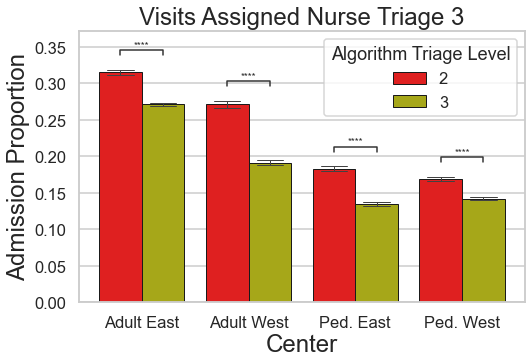

In [3]:
from statannotations.Annotator import Annotator

# keep only patients with nurse triage of 3
df_plt = df[df[acuity_col]==3]
plt_args = dict(
    data = df_plt,
    x = 'Center',
    y = 'is_admitted',
    hue = 'Algorithm Triage Level',
)
ax = sns.barplot(
    **plt_args,
    # palette=['r','y'],
    palette= ['#FF0000', '#BEBE02'],
    edgecolor='k',
    linewidth=1.0,
    errwidth=1.0,
    capsize=0.25,
)
ax.set_xticklabels(['Adult East','Adult West','Ped. East','Ped. West'])
# ax.text(-1.28,0.37,'A)',fontsize=28,fontweight='bold')
# ax.text(-.15,0.97, 'E)', ha='left', va='bottom', transform=ax.transAxes, fontsize=28,fontweight='bold')

plt.gcf().set_figwidth(8)
plt.gcf().set_figheight(5)
ax.set_xlabel(ax.get_xlabel(), fontsize=24)
ax.set_ylabel('Admission Proportion',fontsize=24)
ax.set_title('Visits Assigned Nurse Triage 3',fontsize=24)
pairs=[((center, 3), (center, 2)) for center in center_map.values()]
annotator = Annotator(ax, pairs, **plt_args)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()
plt.savefig('paper/figures/admission_proportion_by_esi_center_3.pdf',dpi=400, bbox_inches='tight')

/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


acuity 2.0
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Adult West_2 vs. Adult West_3: Mann-Whitney-Wilcoxon test two-sided, P_val:4.713e-183 U_stat=9.980e+07
Adult East_2 vs. Adult East_3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.670e-51 U_stat=2.165e+09
Pediatric East_2 vs. Pediatric East_3: Mann-Whitney-Wilcoxon test two-sided, P_val:6.128e-03 U_stat=6.533e+08
Pediatric West_2 vs. Pediatric West_3: Mann-Whitney-Wilcoxon test two-sided, P_val:1.881e-72 U_stat=7.649e+08
acuity 3.0
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Adult West_2 vs. Adult West_3: Mann-Whitney-Wilcoxon test two-sided, P_val:7.716e-147 U_stat=7.331e+08
Adult East_2 vs. Adult East_3: Mann-Whitney-Wilcoxon test two-side

/var/folders/mw/j_dyskd90g71r91fkcf2v95h0000gn/T/ipykernel_45099/464514307.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


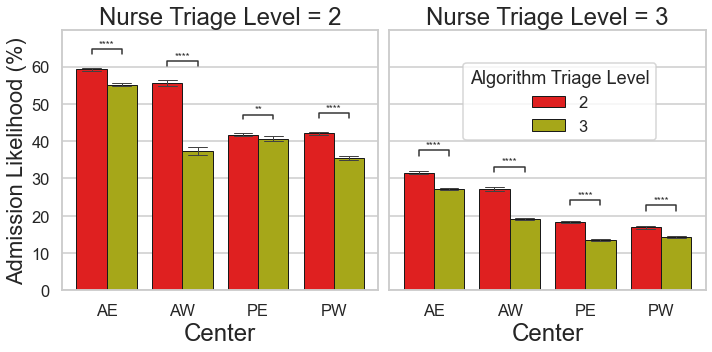

In [4]:
from statannotations.Annotator import Annotator

# keep only patients with nurse triage of 3
# df_plt = df[df[acuity_col]==3
df_plt = df.copy()
df_plt['is_admitted'] *= 100
plt_args = dict(
    data = df_plt,
    x = 'Center',
    y = 'is_admitted',
    hue = 'Algorithm Triage Level',
)
g = sns.catplot(
    kind='bar',
    col=acuity_col,
    **plt_args,
    # palette=['r','y'],
    palette= ['#FF0000', '#BEBE02'],
    edgecolor='k',
    linewidth=1.0,
    errwidth=1.0,
    capsize=0.25,
    aspect=1,
    height=5
)
# g.set_xticklabels(['Adult East','Adult West','Ped. East','Ped. West'])
g.set_xticklabels(['AE','AW','PE','PW'])
g.set_titles(template='Nurse Triage Level = {col_name:.0f}', fontsize=24)
sns.move_legend(g, loc=[.65,.6], frameon=True)

# plt.gcf().set_figwidth(8)
# plt.gcf().set_figheight(5)
for k,ax in g.axes_dict.items():
    ax.set_xlabel(ax.get_xlabel(), fontsize=24)
    ax.set_ylabel('Admission Likelihood (%)',fontsize=22)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.set_title(ax.get_title(),fontsize=24)
    pairs=[((center, 3), (center, 2)) for center in center_map.values()]
    print(acuity_col,k)
    df_tmp = df_plt[df_plt[acuity_col]==k]
    plt_args['data'] = df_tmp
    annotator = Annotator(ax, pairs, **plt_args)
    annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
    annotator.apply_and_annotate()
# g.tight_layout()
plt.gcf().set_figwidth(10)
plt.tight_layout()
print(plt.gcf().get_figheight())
print(plt.gcf().get_figwidth())
plt.savefig('paper/figures/admission_proportion_by_esi_center.pdf',dpi=400, bbox_inches='tight')

In [5]:
df_alg2 = (
    df[
        (df[acuity_col]==3)
        & (df['Algorithm Triage Level']==2)
    ]
    .groupby('Center')
    ['is_admitted']
    .mean()
)
df_alg3 = (
    df[
        (df[acuity_col]==3)
        & (df['Algorithm Triage Level']==3)
    ]
    .groupby('Center')
    ['is_admitted']
    .mean()
)
print('Admission proportion, Alg Triage = 2')
display(df_alg2)
print('Admission proportion, Alg Triage = 3')
display(df_alg3)

print('Likelihood Ratio')
display((df_alg2/df_alg3).round(2))

print('% increase in admission proportion')
display(((df_alg2-df_alg3)/df_alg3*100).round(1))

Admission proportion, Alg Triage = 2


Center
Adult East        0.315538
Adult West        0.271212
Pediatric East    0.182959
Pediatric West    0.168862
Name: is_admitted, dtype: float64

Admission proportion, Alg Triage = 3


Center
Adult East        0.271204
Adult West        0.191244
Pediatric East    0.134316
Pediatric West    0.142083
Name: is_admitted, dtype: float64

Likelihood Ratio


Center
Adult East        1.16
Adult West        1.42
Pediatric East    1.36
Pediatric West    1.19
Name: is_admitted, dtype: float64

% increase in admission proportion


Center
Adult East        16.3
Adult West        41.8
Pediatric East    36.2
Pediatric West    18.8
Name: is_admitted, dtype: float64

/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


2
3
5.0
10.0


/var/folders/mw/j_dyskd90g71r91fkcf2v95h0000gn/T/ipykernel_45099/1341887462.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


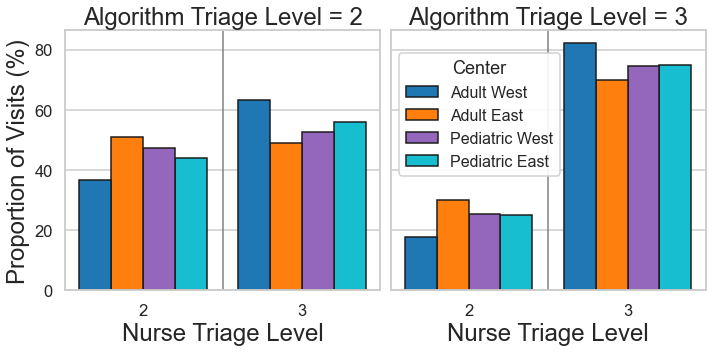

In [18]:
df['Triage Alignment'] = df['Algorithm Triage Level'] == df['acuity']
palette_map = {
    'Adult West': '#1F77B4',
    'Adult East': '#FF7F0E',
    'Pediatric West': '#9467BD',
    'Pediatric East': '#17BECF',
}
g = sns.displot(
    kind='hist',
    discrete=True,
    multiple='dodge',
    stat='percent',
    common_norm=False,
    # estimator='count',
    data = df,
    # y = 'Triage Alignment',
    # x = 'Center',
    hue = 'Center',
    hue_order=list(palette_map.keys()),
    col = 'Algorithm Triage Level',
    x = 'acuity',
    edgecolor='k',
    shrink=0.8,
    alpha=1.0,
    # palette='colorblind',
    height=5,
    aspect=1,
    palette=palette_map
)
# Adult West: Blue (#1F77B4)
# Adult East: Orange (#FF7F0E)
# Pediatric West: Purple (#9467BD)
# Pediatric East: Teal (#17BECF)
sns.move_legend(g,loc=[.56,0.5],frameon=True,framealpha=0.9, fontsize=16)
for k,ax in g.axes_dict.items():
    print(k)
    ax.axvline(x=2.5,linestyle='-',color='gray',linewidth=1.5)
    ax.set_xlabel('Nurse Triage Level',fontsize=24)
    ax.set_xticks([2,3],['2','3'])
    # ax.
    ax.grid(visible=False,axis='x')
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.set_title(ax.get_title(), fontsize=24)
    if k == 2:
        ax.set_ylabel('Proportion of Visits (%)')
    ax.set_ylabel(ax.get_ylabel(), fontsize=24)    
# g.axes.flat[0].text(1.3,0.85,'D)',fontsize=28,fontweight='bold')

# plt.gcf().set_figwidth(14)
plt.gcf().set_figwidth(10)
plt.tight_layout()
print(plt.gcf().get_figheight())
print(plt.gcf().get_figwidth())
# plt.tight_layout()
plt.savefig('paper/figures/handbook_vs_nurse_esi.pdf',dpi=400, bbox_inches='tight')
    

/Users/bill/miniforge3/envs/esi/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


5.0


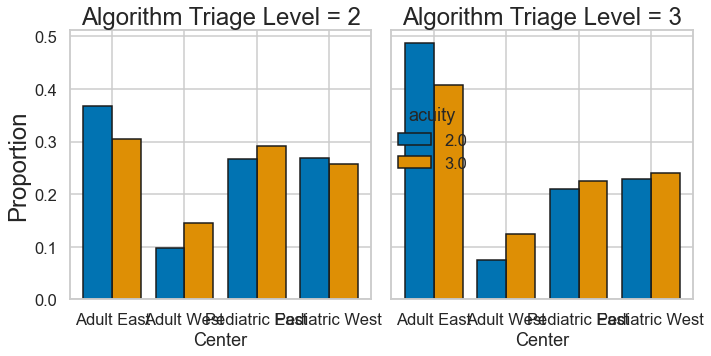

In [7]:
df['Triage Alignment'] = df['Algorithm Triage Level'] == df['acuity']
g = sns.displot(
    kind='hist',
    discrete=True,
    multiple='dodge',
    stat='proportion',
    common_norm=False,
    # estimator='count',
    data = df,
    # y = 'Triage Alignment',
    # x = 'Center',
    x = 'Center',
    col = 'Algorithm Triage Level',
    hue = 'acuity',
    edgecolor='k',
    shrink=0.8,
    alpha=1.0,
    palette='colorblind',
    height=5,
    aspect=1
)
sns.move_legend(g,loc=[.55,0.5],frameon=False,framealpha=0.0) #, fontsize=16)
# g.set_xticklabels(['AE','AW','PE','PW'])
# g.set_titles(template='Nurse Triage Level = {col_name:.0f}')
for k,ax in g.axes_dict.items():
    # ax.axvline(x=2.5,linestyle='-',color='gray',linewidth=1.5)
    # ax.set_xlabel('Nurse Triage Level',fontsize=24)
    # ax.set_xticks([2,3],['2','3'])
    # ax.
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.set_title(ax.get_title(), fontsize=24)
    ax.set_ylabel(ax.get_ylabel(), fontsize=24)    
# g.axes.flat[0].text(1.3,0.85,'D)',fontsize=28,fontweight='bold')

# plt.gcf().set_figwidth(14)
print(plt.gcf().get_figheight())
# plt.tight_layout()
# plt.savefig('paper/figures/handbook_vs_nurse_esi.pdf',dpi=400, bbox_inches='tight')
    

## Admission probability

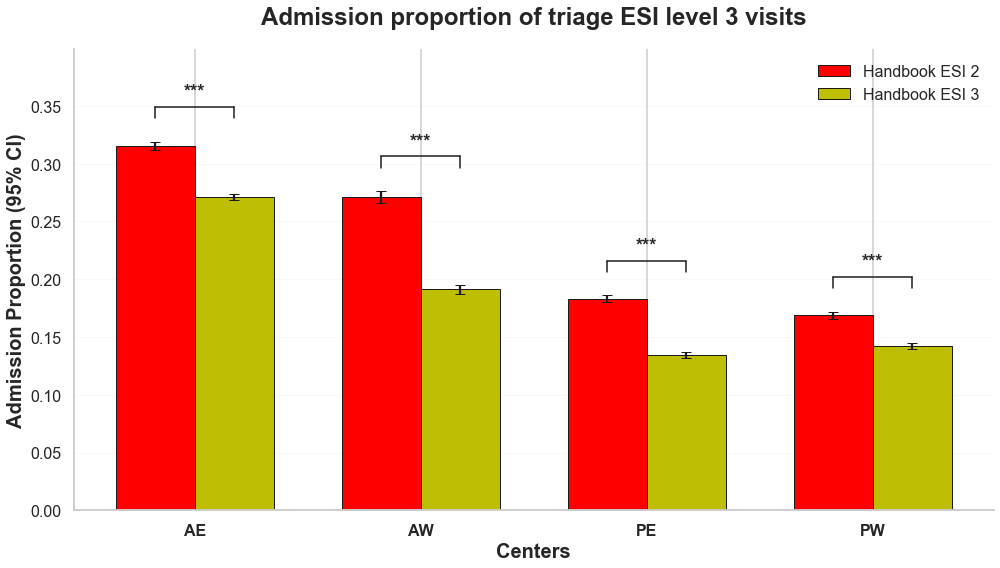

In [8]:
from statsmodels.stats.proportion import proportion_confint

def calculate_admission_probability(data, center_name):
    """Calculate admisison probability and CI"""
    
    # Filter for triage acuity 3 patients only
    acuity_cols = [col for col in data.columns if 'acuity' in col.lower()]
    if not acuity_cols:
        print(f"Warning: No acuity column found in {center_name}!")
        return {}
    
    acuity_col = acuity_cols[0]  
    triage_3_patients = data[data[acuity_col] == 3].copy()
    
    results = {}
    
    for flag_status in [0, 1]:
        patients = triage_3_patients[triage_3_patients['any_flagged'] == flag_status]
        
        if len(patients) == 0:
            continue
            
        admitted = patients['is_admitted'].sum()
        total = len(patients)
        probability = admitted / total
        
        # Calculate 95% CI using Wilson score interval
        ci_lower, ci_upper = proportion_confint(admitted, total, alpha=0.05, method='wilson')
        
        esi_level = 'ESI 2' if flag_status == 1 else 'ESI 3'
        results[esi_level] = {
            'probability': probability,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'admitted': admitted,
            'total': total,
            'patients_data': patients  # Store for significance testing
        }
    
    return results

def perform_significance_test_per_center(center_stats):
    """Perform t-test for HB ESI 2 vs HB ESI 3 within each center"""
    
    # Extract admission data and perform t-test in one line
    t_stat, p_value = stats.ttest_ind(
        center_stats['ESI 2']['patients_data']['is_admitted'].values,
        center_stats['ESI 3']['patients_data']['is_admitted'].values
    )
    
    return p_value

# Define centers 
centers = ['BIDMC', 'Stanford', 'BCH', 'CHLA']

# Initialize results
all_stats = {}
p_values = {}

for center in centers:
    # print(f"\nProcessing {center} dataset...")
    all_stats[center] = calculate_admission_probability(datasets[center], center)
    p_values[center] = perform_significance_test_per_center(all_stats[center])
    # print(f"{center} significance test (ESI 2 vs ESI 3): p = {p_values[center]:.6f}")

# Initialize figure
fig, ax = plt.subplots(1, 1, figsize=(14, 8), facecolor='white')

# Set up positions for bars
bar_width = 0.35
center_spacing = 1.0
x_positions = np.arange(len(centers)) * center_spacing
x_labels = ['AE', 'AW', 'PE', 'PW']  # Center labels

# Define colors
esi_colors = ['#FF0000', '#BEBE02']  

# Store bar positions and heights for significance annotation
bar_positions = {}
bar_heights = {}

# Plot bars for each ESI level
for j, esi_level in enumerate(['ESI 2', 'ESI 3']):
    probabilities = []
    ci_lowers = []
    ci_uppers = []
    
    # Get data for each center
    for center in centers:
        esi_data = all_stats[center].get(esi_level, {})
        
        if esi_data:
            probabilities.append(esi_data['probability'])
            ci_lowers.append(esi_data['ci_lower'])
            ci_uppers.append(esi_data['ci_upper'])
        else:
            probabilities.append(0)
            ci_lowers.append(0)
            ci_uppers.append(0)
    
    # Calculate error bars
    yerr_lower = [probabilities[i] - ci_lowers[i] for i in range(len(probabilities))]
    yerr_upper = [ci_uppers[i] - probabilities[i] for i in range(len(probabilities))]
    
    # Calculate x positions for this ESI level's bars
    x_pos = x_positions + (j - 0.5) * bar_width
    
    # Store positions and heights for significance annotation
    if j == 0:  # Initialize for first ESI level
        for i, center in enumerate(centers):
            bar_positions[center] = [x_pos[i]]
            bar_heights[center] = [probabilities[i] + yerr_upper[i]]
    else:  # Add second position for ESI 3
        for i, center in enumerate(centers):
            bar_positions[center].append(x_pos[i])
            bar_heights[center].append(probabilities[i] + yerr_upper[i])
    
    # Plot bars
    bars = ax.bar(x_pos, probabilities, bar_width, 
                  label=f'Handbook {esi_level}', color=esi_colors[j], alpha=1,
                  yerr=[yerr_lower, yerr_upper], capsize=5,
                  edgecolor='k', linewidth=1)

# Add significance annotations for each center
for i, center in enumerate(centers):
    if p_values[center] < 0.05:
        x_pos = bar_positions[center]
        heights = bar_heights[center]
        
        # Find the maximum height for this center's bars
        max_height = max(heights)
        
        # Position for the bracket
        bracket_height = max_height + 0.02
        line_height = bracket_height + 0.01
        
        # Draw horizontal line connecting the two bars
        ax.plot([x_pos[0], x_pos[1]], [line_height, line_height], 'k-', linewidth=1.5)
        
        # Draw vertical lines at each end
        ax.plot([x_pos[0], x_pos[0]], [bracket_height, line_height], 'k-', linewidth=1.5)
        ax.plot([x_pos[1], x_pos[1]], [bracket_height, line_height], 'k-', linewidth=1.5)
        
        # Add significance stars with larger font
        stars = '***' if p_values[center] < 0.001 else '**' if p_values[center] < 0.01 else '*'
        ax.text(np.mean(x_pos), line_height + 0.005, stars, 
               ha='center', va='bottom', fontsize=18, fontweight='bold')

ax.set_title('Admission proportion of triage ESI level 3 visits', 
            fontsize=24, fontweight='bold', pad=25)
ax.set_ylabel('Admission Proportion (95% CI)', fontsize=20, fontweight='bold')
ax.set_xlabel('Centers', fontsize=20, fontweight='bold')

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=16, fontweight='bold')
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=16)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(fontsize=16, loc='upper right', frameon=False)

ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='lightgray')
ax.set_axisbelow(True)
ax.set_facecolor('white')

# Set y-axis limit (account for significance annotations)
max_y = 0
for center in centers:
    for esi_level in ['ESI 2', 'ESI 3']:
        if esi_level in all_stats[center]:
            max_y = max(max_y, all_stats[center][esi_level]['ci_upper'])

# Add extra space if any center has significant results
has_significant = any(p < 0.05 for p in p_values.values())
y_limit = max_y * 1.25 if has_significant else max_y * 1.1
ax.set_ylim(0, y_limit)

plt.tight_layout()
plt.show()

## Figure 1E: Triage Acuity Probability

### Option 1: stacked bar plots

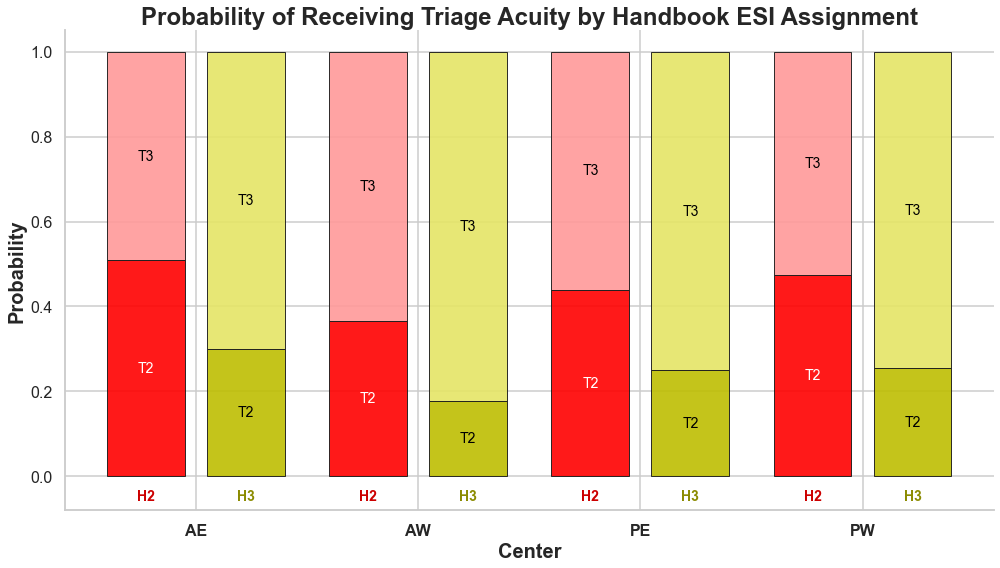

In [9]:
def plot_triage_probability_v1(datasets, centers):
    
    """One column per center per handbook level with stacked triage levels"""
    
    # Process each center
    all_results = {}
    for center in centers:
        data = datasets[center]
        
        # Find triage acuity column (column name may vary across centers)
        acuity_cols = [col for col in data.columns if 'acuity' in col.lower()]
        if not acuity_cols:
            print(f"Warning: No acuity column found in {center}!")
            continue
        triage_acuity_col = acuity_cols[0]
        
        results = []
        
        # For each handbook ESI level (flagged vs unflagged)
        for flagged in [True, False]:
            handbook_label = 'Handbook ESI 2' if flagged else 'Handbook ESI 3'
            
            # For each triage acuity level
            for triage_acuity in [2, 3]:
                
                # Get all patients in this handbook ESI level
                handbook_patients = data[data['any_flagged'] == flagged]
                
                # Count successes (patients who got the specified triage acuity)
                success = (handbook_patients[triage_acuity_col] == triage_acuity).sum()
                total = len(handbook_patients)
                
                # Calculate probability
                probability = success / total if total > 0 else 0
                
                # Store results
                results.append({
                    'Center': center,
                    'Handbook_ESI': handbook_label,
                    'Triage_Acuity': triage_acuity,
                    'Category': f'H{2 if flagged else 3}/T{triage_acuity}',
                    'Success': success,
                    'Total': total,
                    'Probability': probability,
                })
        
        all_results[center] = pd.DataFrame(results)
    
    # Initialize figure
    fig, ax = plt.subplots(1, 1, figsize=(14, 8), facecolor='white')
    
    # Colors
    h2_t2_color = '#FF0000'  # Dark red 
    h2_t3_color = '#FF9999'  # Light red
    h3_t2_color = '#BEBE02'  # Dark yellow-green
    h3_t3_color = '#E5E566'  # Light yellow-green
    
    
    # Bar positions
    n_centers = len(centers)
    bar_width = 0.35  # Width of each bar
    group_spacing = 1.0  # Space between centers
    x_center_positions = np.arange(n_centers) * group_spacing
    
    # Offset for H2 and H3 bars within each center
    h2_offset = -bar_width/2 - 0.05
    h3_offset = bar_width/2 + 0.05
    
    # Plot bars for each center
    for i, center in enumerate(centers):
        if center not in all_results:
            continue
            
        center_data = all_results[center]
        center_x = x_center_positions[i]
        
        # Get probabilities for Handbook 2
        h2_t2 = center_data[center_data['Category'] == 'H2/T2']['Probability'].iloc[0] if not center_data[center_data['Category'] == 'H2/T2'].empty else 0
        h2_t3 = center_data[center_data['Category'] == 'H2/T3']['Probability'].iloc[0] if not center_data[center_data['Category'] == 'H2/T3'].empty else 0
        
        # Get probabilities for Handbook 3
        h3_t2 = center_data[center_data['Category'] == 'H3/T2']['Probability'].iloc[0] if not center_data[center_data['Category'] == 'H3/T2'].empty else 0
        h3_t3 = center_data[center_data['Category'] == 'H3/T3']['Probability'].iloc[0] if not center_data[center_data['Category'] == 'H3/T3'].empty else 0
        
        # Plot Handbook 2 stacked bar
        ax.bar(center_x + h2_offset, h2_t2, bar_width, 
               color=h2_t2_color, alpha=0.9,
               edgecolor='k', linewidth=1,
               label='H2/Triage 2' if i == 0 else '')
        ax.bar(center_x + h2_offset, h2_t3, bar_width, 
               bottom=h2_t2,
               color=h2_t3_color, alpha=0.9,
               edgecolor='k', linewidth=1,
               label='H2/Triage 3' if i == 0 else '')
        
        # Plot Handbook 3 stacked bar 
        ax.bar(center_x + h3_offset, h3_t2, bar_width, 
               color=h3_t2_color, alpha=0.9,
               edgecolor='k', linewidth=1,
               label='H3/Triage 2' if i == 0 else '')
        ax.bar(center_x + h3_offset, h3_t3, bar_width, 
               bottom=h3_t2,
               color=h3_t3_color, alpha=0.9,
               edgecolor='k', linewidth=1,
               label='H3/Triage 3' if i == 0 else '')
        
        # Add T2 and T3 labels on the bars
        ax.text(center_x + h2_offset, h2_t2/2, 'T2', 
                    ha='center', va='center', fontsize=14, color='white')
        ax.text(center_x + h2_offset, h2_t2 + h2_t3/2, 'T3', 
                ha='center', va='center', fontsize=14, color='black')
        
        ax.text(center_x + h3_offset, h3_t2/2, 'T2', 
                ha='center', va='center', fontsize=14, color='black')
        ax.text(center_x + h3_offset, h3_t2 + h3_t3/2, 'T3', 
                ha='center', va='center', fontsize=14, color='black')
        
        # Add Handbook labels
        ax.text(center_x + h2_offset, -0.03, 'H2', 
                ha='center', va='top', fontsize=14, fontweight='bold', color='#CC0000')
        ax.text(center_x + h3_offset, -0.03, 'H3', 
                ha='center', va='top', fontsize=14, fontweight='bold', color='#8B8B01')
    
    ax.set_title('Probability of Receiving Triage Acuity by Handbook ESI Assignment', 
                fontsize=24, fontweight='bold')
    ax.set_ylabel('Probability', fontsize=20, fontweight='bold')
    ax.set_xlabel('Center', fontsize=20, fontweight='bold')
    
    ax.set_xticks(x_center_positions)
    ax.set_xticklabels(['AE', 'AW', 'PE', 'PW'], fontsize=16, fontweight='bold')
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=16)
    
    ax.set_ylim(-0.08, 1.05)  
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return all_results

# Define datasets
centers = ['BIDMC', 'Stanford', 'BCH', 'CHLA']

# Plot triage probabilities
esi_results = plot_triage_probability_v1(datasets, centers)

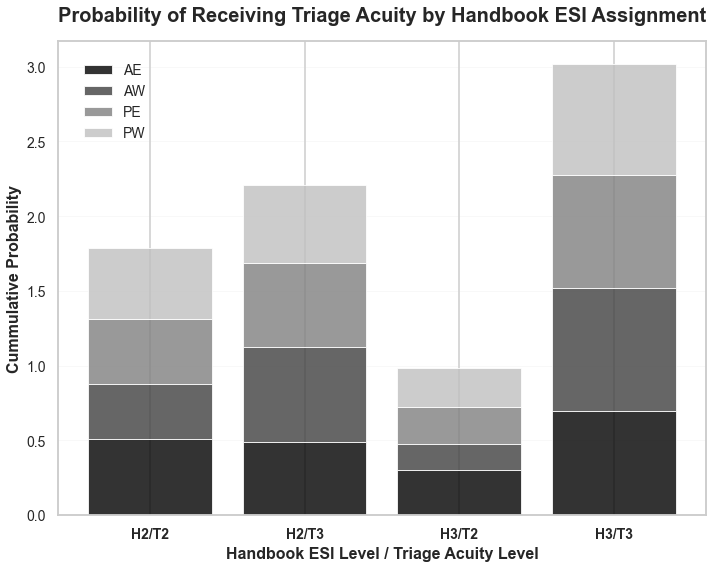

In [10]:
def plot_triage_probability_v1(datasets, centers):
    """Non-stacked bar plot for triage probability"""
    
    # Process each center
    all_results = {}
    for center in centers:
        data = datasets[center]
        
        # Find triage acuity column (column name may vary accross centers)
        acuity_cols = [col for col in data.columns if 'acuity' in col.lower()]
        if not acuity_cols:
            print(f"Warning: No acuity column found in {center}!")
            continue
        triage_acuity_col = acuity_cols[0]
        
        results = []
        
        # For each handbook ESI level (flagged vs unflagged)
        for flagged in [True, False]:
            handbook_label = 'Handbook ESI 2' if flagged else 'Handbook ESI 3'
            
            # For each triage acuity level
            for triage_acuity in [2, 3]:
                
                # Get all patients in this handbook ESI level
                handbook_patients = data[data['any_flagged'] == flagged]
                
                # Count successes (patients who got the specified triage acuity)
                success = (handbook_patients[triage_acuity_col] == triage_acuity).sum()
                total = len(handbook_patients)
                
                # Calculate probability
                probability = success / total if total > 0 else 0
                
                # Store results
                results.append({
                    'Center': center,
                    'Handbook_ESI': handbook_label,
                    'Triage_Acuity': triage_acuity,
                    'Category': f'H{2 if flagged else 3}/T{triage_acuity}',
                    'Success': success,
                    'Total': total,
                    'Probability': probability,
                })
        
        all_results[center] = pd.DataFrame(results)
    
    # Initialize figure
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), facecolor='white')
    
    # Define categories and colors
    categories = ['H2/T2', 'H2/T3', 'H3/T2', 'H3/T3']
    #colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']  # old colors
    colors = ['#000000', '#404040', '#808080', '#C0C0C0']
    
    # Define bar positions
    bar_width = 0.8
    x_positions = np.arange(len(categories))
    bottom_positions = np.zeros(len(categories))
    
    # Plot stacked bars for each center
    for i, center in enumerate(centers):
        if center not in all_results:
            continue
            
        center_data = all_results[center]
        
        # Get data for each category
        probabilities = []
        
        for category in categories:
            cat_data = center_data[center_data['Category'] == category]
            if not cat_data.empty:
                probabilities.append(cat_data['Probability'].iloc[0])
            else:
                probabilities.append(0)
        
        # Plot stacked bars 
        ax.bar(x_positions, probabilities, bar_width, 
                  bottom=bottom_positions,
                  label=center, color=colors[i], alpha=0.8,
                  edgecolor='white', linewidth=1)
        
        # Update bottom positions for next stack
        bottom_positions += probabilities
    
    ax.set_title('Probability of Receiving Triage Acuity by Handbook ESI Assignment', 
                fontsize=20, fontweight='bold', pad=20)
    ax.set_ylabel('Cummulative Probability', fontsize=16, fontweight='bold')
    ax.set_xlabel('Handbook ESI Level / Triage Acuity Level', fontsize=16, fontweight='bold')
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories, fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=14)
    
    ax.legend(['AE', 'AW', 'PE', 'PW'], fontsize=14, loc='upper left', frameon=False, 
              bbox_to_anchor=(0.02, 0.98))

    ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='lightgray')
    ax.set_axisbelow(True)
    ax.set_facecolor('white')
    
    max_stacked_height = np.max(bottom_positions)
    ax.set_ylim(0, max_stacked_height * 1.05)
    
    plt.tight_layout()
    plt.show()
    
    return all_results

# Define datasets
centers = ['BIDMC', 'Stanford', 'BCH', 'CHLA']  # Fixed the duplicate centers

# Plot triage probabilities
esi_results = plot_triage_probability_v1(datasets, centers)

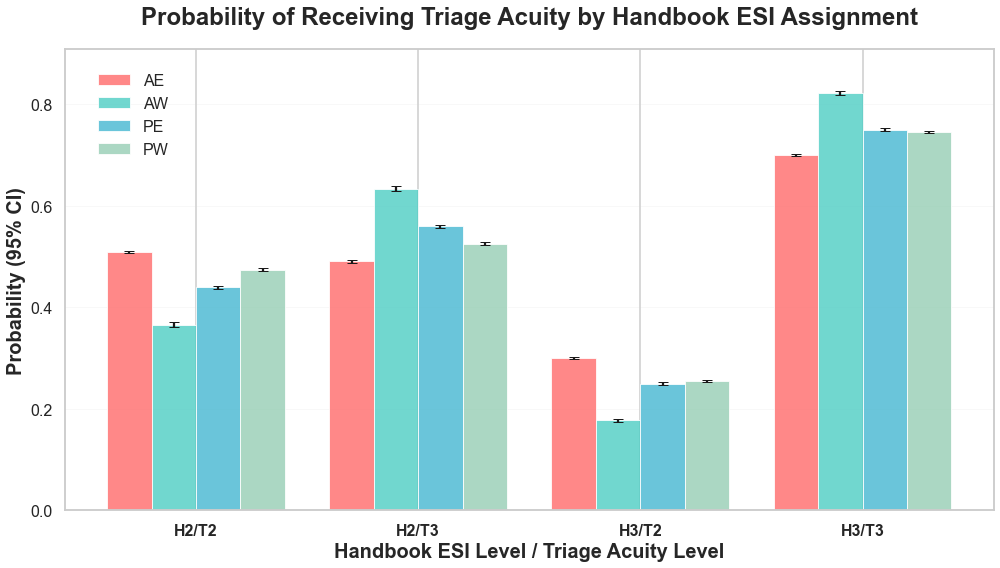

In [11]:
from statsmodels.stats.proportion import proportion_confint

def plot_triage_probability_v2(datasets, centers):
    """Stacked bar plot for triage probability"""
    
    # Process each center
    all_results = {}
    for center in centers:
        data = datasets[center]
        
        # Find triage acuity column
        acuity_cols = [col for col in data.columns if 'acuity' in col.lower()]
        if not acuity_cols:
            print(f"Warning: No acuity column found in {center}!")
            continue
        triage_acuity_col = acuity_cols[0]
        
        results = []
        
        # For each handbook ESI level (flagged vs unflagged)
        for flagged in [True, False]:
            handbook_label = 'Handbook ESI 2' if flagged else 'Handbook ESI 3'
            
            # For each triage acuity level
            for triage_acuity in [2, 3]:
                
                # Get all patients in this handbook ESI level
                handbook_patients = data[data['any_flagged'] == flagged]
                
                # Count successes (patients who got the specified triage acuity)
                success = (handbook_patients[triage_acuity_col] == triage_acuity).sum()
                total = len(handbook_patients)
                
                # Calculate probability
                probability = success / total if total > 0 else 0
                
                # Calculate 95% CI using Wilson score interval
                if total > 0:
                    ci_lower, ci_upper = proportion_confint(success, total, alpha=0.05, method='wilson')
                else:
                    ci_lower = ci_upper = probability
                
                # Store results
                results.append({
                    'Center': center,
                    'Handbook_ESI': handbook_label,
                    'Triage_Acuity': triage_acuity,
                    'Category': f'H{2 if flagged else 3}/T{triage_acuity}',
                    'Success': success,
                    'Total': total,
                    'Probability': probability,
                    'CI_Lower': ci_lower,
                    'CI_Upper': ci_upper
                })
        
        all_results[center] = pd.DataFrame(results)
    
    # Initialize figure
    fig, ax = plt.subplots(1, 1, figsize=(14, 8), facecolor='white')
    
    # Define categories and colors
    categories = ['H2/T2', 'H2/T3', 'H3/T2', 'H3/T3']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']  # Same colors as centers
    
    # Set up bar positions
    bar_width = 0.2
    x_positions = np.arange(len(categories))
    
    # Plot bars for each center
    for i, center in enumerate(centers):
        if center not in all_results:
            continue
            
        center_data = all_results[center]
        
        # Get data for each category
        probabilities = []
        ci_lowers = []
        ci_uppers = []
        
        for category in categories:
            cat_data = center_data[center_data['Category'] == category]
            if not cat_data.empty:
                probabilities.append(cat_data['Probability'].iloc[0])
                ci_lowers.append(cat_data['CI_Lower'].iloc[0])
                ci_uppers.append(cat_data['CI_Upper'].iloc[0])
            else:
                probabilities.append(0)
                ci_lowers.append(0)
                ci_uppers.append(0)
        
        # Calculate error bars
        yerr_lower = [probabilities[j] - ci_lowers[j] for j in range(len(probabilities))]
        yerr_upper = [ci_uppers[j] - probabilities[j] for j in range(len(probabilities))]
        
        # Calculate x positions for this center's bars
        x_pos = x_positions + (i - 1.5) * bar_width
        
        # Plot bars
        ax.bar(x_pos, probabilities, bar_width, 
                  label=center, color=colors[i], alpha=0.8,
                  yerr=[yerr_lower, yerr_upper], capsize=5,
                  edgecolor='white', linewidth=1)
    
    ax.set_title('Probability of Receiving Triage Acuity by Handbook ESI Assignment', 
                fontsize=24, fontweight='bold', pad=25)
    ax.set_ylabel('Probability (95% CI)', fontsize=20, fontweight='bold')
    ax.set_xlabel('Handbook ESI Level / Triage Acuity Level', fontsize=20, fontweight='bold')
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories, fontsize=16, fontweight='bold')
    ax.tick_params(axis='y', labelsize=16) 
    ax.tick_params(axis='x', labelsize=16)  
    
    ax.legend(['AE', 'AW', 'PE', 'PW'], fontsize=16, loc='upper left', frameon=False, 
              bbox_to_anchor=(0.02, 0.98))  
    
    ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='lightgray')
    ax.set_axisbelow(True)
    ax.set_facecolor('white')  
    
    # Set y-axis limit
    max_y = 0
    for center in centers:
        if center in all_results:
            center_max = all_results[center]['CI_Upper'].max()
            max_y = max(max_y, center_max)
    
    ax.set_ylim(0, max_y * 1.1)
    
    plt.tight_layout()
    plt.show()
    
    return all_results

# Usage with your existing datasets:
centers = ['BIDMC', 'Stanford', 'BCH', 'CHLA']  # Fixed the duplicate centers

# Calculate ESI probabilities by center
results = plot_triage_probability_v2(datasets, centers)